<a href="https://colab.research.google.com/github/anyakdard/ocean-acoustics/blob/main/03_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

# new machine learning libraries
import tensorflow as tf
# tensorflow Google's open source machine learning framework
# most widely used library for building neural networks

from tensorflow import keras
# keras high level API built on top of tensorflow
# makes building neural networks readable n concise

print('TensorFlow version:', tf.__version__)
print('Ready!')

TensorFlow version: 2.20.0
Ready!


In [2]:
# Reinstall awscli
!pip install awscli -q
# -q means quiet - suppresses the installation output so it's less cluttered

# Re-download the data
!aws s3 cp s3://acoustic-sandbox/labeled-data/detection/train/TestDataLatest_PodCastAllRounds_123.tar.gz /content/orcadata.tar.gz --no-sign-request

# Extract it
!mkdir -p /content/orcadata
!tar -xzf /content/orcadata.tar.gz -C /content/orcadata

print('Data ready!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 77.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.5/570.5 kB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.6/88.6 kB 6.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sphinx 8.2.3 requires docutils<0.22,>=0.20, but you have docutils 0.19 which is incompatible.
download: s3://acoustic-sandbox/labeled-data/detection/train/TestDataLatest_PodCastAllRounds_123.tar.gz to ./orcadata.tar.gz
Data ready!


In [3]:
# SET UP CELL:
import librosa
import librosa.display

plt.ioff()

# Recreate orca spectrograms
os.makedirs('/content/spectrograms/orca', exist_ok=True)
os.makedirs('/content/spectrograms/noise', exist_ok=True)

df = pd.read_csv('/content/orcadata/test.tsv', sep='\t')

# Generate orca call spectrograms
failed = []
for i, row in df.iterrows():
    wav_path = f'/content/orcadata/wav/{row["wav_filename"]}'
    if not os.path.exists(wav_path):
        failed.append(i)
        continue
    try:
        y, sr = librosa.load(wav_path, offset=row['start_time_s'],
                             duration=row['duration_s'])
        M = librosa.feature.melspectrogram(y=y, sr=sr)
        M_db = librosa.amplitude_to_db(M, ref=np.max)
        fig = plt.figure(figsize=(2, 2))
        ax = fig.add_subplot(111)
        librosa.display.specshow(M_db, sr=sr, ax=ax)
        ax.axis('off')
        plt.savefig(f'/content/spectrograms/orca/call_{i:04d}.png',
                    bbox_inches='tight', pad_inches=0)
        plt.close(fig)
    except Exception:
        failed.append(i)

print(f'Orca spectrograms: {len(os.listdir("/content/spectrograms/orca"))}')

# Generate noise spectrograms
noise_counter = 0
for wav_filename, group in df.groupby('wav_filename'):
    call_times = list(zip(group['start_time_s'],
                          group['start_time_s'] + group['duration_s']))
    wav_path = f'/content/orcadata/wav/{wav_filename}'
    if not os.path.exists(wav_path):
        continue
    total_duration = librosa.get_duration(path=wav_path)
    total_call_time = sum(end - start for start, end in call_times)
    coverage = total_call_time / total_duration
    adjusted_snippets = max(1, int(10 * (1 - coverage)))
    saved = 0
    attempts = 0
    while saved < adjusted_snippets and attempts < 500:
        attempts += 1
        start = random.uniform(0, total_duration - 1.5)
        end = start + 1.5
        overlaps = False
        for call_start, call_end in call_times:
            if start < call_end and end > call_start:
                overlaps = True
                break
        if overlaps:
            continue
        try:
            y, sr = librosa.load(wav_path, offset=start, duration=1.5)
            M = librosa.feature.melspectrogram(y=y, sr=sr)
            M_db = librosa.amplitude_to_db(M, ref=np.max)
            fname = f'/content/spectrograms/noise/noise_{noise_counter:05d}.png'
            noise_counter += 1
            fig = plt.figure(figsize=(2, 2))
            ax = fig.add_subplot(111)
            librosa.display.specshow(M_db, sr=sr, ax=ax)
            ax.axis('off')
            plt.savefig(fname, bbox_inches='tight', pad_inches=0)
            plt.close(fig)
            saved += 1
        except Exception:
            continue

print(f'Noise spectrograms: {len(os.listdir("/content/spectrograms/noise"))}')
print('All ready!')

/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=0
  warnings.warn(


Orca spectrograms: 828
Noise spectrograms: 1026
All ready!


In [4]:
# loading images into numpy arrays that the model can read


from tensorflow.keras.preprocessing.image import load_img, img_to_array
# load_img opens an image file
# img_to_array converts it into a numpy array of pixel values

# resize every image to the same fixed size
# Neural networks need all inputs to be identical dimensions
# 128x128 pixels is a good balance - big enough to see call patterns,
# small enough to train quickly
IMG_SIZE = (128, 128)
# This is a tuple - an immutable ordered pair of values
# Tuples use () instead of lists which use []
# Immutable means you can't change the values after creating it

images = []
labels = []
# Two empty lists - images will hold pixel arrays, labels will hold 0 or 1

# Load orca calls - label 1 means "yeah orca call"
orca_dir = '/content/spectrograms/orca'
for fname in os.listdir(orca_dir):
    if fname.endswith('.png'):
        # endswith() checks if a string ends with a given suffix
        img = load_img(os.path.join(orca_dir, fname), target_size=IMG_SIZE)
        # os.path.join() safely combines folder path and filename
        # e.g. '/content/spectrograms/orca' + 'call_0001.png'
        # = '/content/spectrograms/orca/call_0001.png'
        arr = img_to_array(img)
        # arr is now a 3D array of shape (128, 128, 3)
        # 128x128 pixels, 3 colour channels (RGB - red, green, blue)
        images.append(arr)
        labels.append(1)

print(f'Orca images loaded: {len(images)}')

# Load noise - label 0 means "no orca call"
noise_dir = '/content/spectrograms/noise'
for fname in os.listdir(noise_dir):
    if fname.endswith('.png'):
        img = load_img(os.path.join(noise_dir, fname), target_size=IMG_SIZE)
        arr = img_to_array(img)
        images.append(arr)
        labels.append(0)

print(f'Total images loaded: {len(images)}')

Orca images loaded: 828
Total images loaded: 1854


In [5]:
# Convert our Python lists into numpy arrays
# Neural networks can't work with Python lists directly
# They need numpy arrays - a more efficient mathematical data structure
X = np.array(images)
y = np.array(labels)
# X is the conventional variable name for input data in machine learning
# y is the conventional variable name for labels/targets
# This convention comes from mathematics - y = f(X)

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

# Normalise pixel values from 0-255 to 0-1
# Currently each pixel is a number between 0 (black) and 255 (white)
# Neural networks train much better when input values are small numbers
# Dividing by 255 scales everything to between 0 and 1
# This is called normalisation - putting values on a standard scale
X = X / 255.0

print(f'Pixel value range: {X.min():.2f} to {X.max():.2f}')
# Should print 0.00 to 1.00

X shape: (1854, 128, 128, 3)
y shape: (1854,)
Pixel value range: 0.00 to 1.00


In [6]:
# those values are the dimensions so 128 x 128 pixels

from sklearn.model_selection import train_test_split
# sklearn (scikit-learn) is the standard Python machine learning library
# train_test_split randomly divides your data into two groups

# Split the data
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    # test_size=0.2 means 20% goes to validation, 80% to training
    # So roughly 1483 images for training, 371 for validation
    random_state=42,
    # random_state=42 fixes the random seed so the split is reproducible
    # meaning if you run this again you get the exact same split
    # 42 is just a convention - any number works
    stratify=y
    # stratify=y ensures the split preserves the ratio of orca to noise
    # without this you might accidentally put all orca calls in training
    # and all noise in validation, which would give misleading results
)

print(f'Training images: {len(X_train)}')
print(f'Validation images: {len(X_val)}')
print(f'Training orca calls: {y_train.sum()}')
print(f'Validation orca calls: {y_val.sum()}')

Training images: 1483
Validation images: 371
Training orca calls: 662
Validation orca calls: 166


In [7]:
# now building neural network

from tensorflow.keras import layers, models
# layers contains all the building blocks of a neural network
# models contains the tools for assembling those blocks together

model = models.Sequential()
# Sequential means the layers are stacked in a straight line
# data flows through them one after another in order
# the alternative is more complex branching architectures
# but Sequential is perfect for what we're building

# INPUT LAYER
model.add(layers.Input(shape=(128, 128, 3)))
# tells the network what shape to expect for each input
# (128, 128, 3) matches our normalised image arrays exactly

# CONVOLUTIONAL BLOCK 1
model.add(layers.Conv2D(32, (3, 3), activation='relu'))
# Conv2D is the core operation of a CNN
# 32 = number of filters - each filter learns to detect a different pattern
# (3, 3) = the size of each filter in pixels - a 3x3 window
# activation='relu' applies a function called ReLU after each convolution
# ReLU stands for Rectified Linear Unit - it simply sets any negative
# values to zero. This sounds trivial but is crucial - without it
# stacking layers would just be one big linear equation
# and the network couldn't learn complex patterns

In [8]:
model.add(layers.MaxPooling2D((2, 2)))
# MaxPooling reduces the image size by taking the maximum value
# in each 2x2 block of pixels
# This makes the network faster and helps it focus on
# the most prominent features rather than exact pixel positions
# After this layer the feature maps are half the size they were

# CONVOLUTIONAL BLOCK 2
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
# 64 filters this time - deeper layers learn more complex patterns
# so we give them more filters to work with
model.add(layers.MaxPooling2D((2, 2)))

# CONVOLUTIONAL BLOCK 3
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
# 128 filters - by this point the network is detecting
# high level features like "sweeping frequency pattern"
# rather than simple edges
model.add(layers.MaxPooling2D((2, 2)))

# FLATTEN
model.add(layers.Flatten())
# After the convolutional layers we have a 3D block of features
# Flatten squashes it into a 1D array so we can feed it
# into regular fully connected layers
# Think of it like unrolling a cube into a long line

# DROPOUT
model.add(layers.Dropout(0.5))
# Dropout randomly switches off 50% of neurons during each
# training step
# This sounds destructive but is actually one of the most
# effective techniques to prevent overfitting
# Overfitting is when a model memorises the training data
# instead of learning general patterns - it performs
# brilliantly on training data but poorly on new data
# Dropout forces the network to learn robust features
# that work even when half the neurons are missing

# FULLY CONNECTED LAYER
model.add(layers.Dense(64, activation='relu'))
# Dense means every neuron connects to every neuron in the previous layer
# This is where the network combines all the features it detected
# into a final decision
# 64 neurons, relu activation same as before

# OUTPUT LAYER
model.add(layers.Dense(1, activation='sigmoid'))
# 1 neuron because we have a binary classification - orca or not orca
# sigmoid activation squashes the output to between 0 and 1
# giving us a probability - e.g. 0.92 means 92% confident it's an orca call
# sigmoid is always used for binary classification output layers

# Print a summary of the architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,605,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,699,009 (6.48 MB)

 Trainable params: 1,699,009 (6.48 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# compiling and training the model

model.compile(
    optimizer='adam',
    # optimizer is the algorithm that adjusts the network's parameters
    # during training to reduce errors
    # adam (Adaptive Moment Estimation) is the most widely used optimizer
    # automatically adjusts how big each parameter update is
    # based on how the training is going - smarter than a fixed learning rate

    loss='binary_crossentropy',
    # loss is the function that measures how wrong the model's predictions are
    # binary_crossentropy is the standard loss for binary classification
    # it heavily penalises confident wrong predictions
    # e.g. predicting 0.99 when the answer is 0 is penalised much more
    # than predicting 0.6 when the answer is 0

    metrics=['accuracy']
    # metrics are what we want to monitor during training
    # accuracy = percentage of correct predictions
    # this is separate from loss - loss is what the model optimises,
    # accuracy is what we humans care about reading
)

# Add early stopping - this stops training automatically if the model
# stops improving, preventing overfitting and wasted compute time
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    # monitor val_loss - validation loss - not training loss
    # we care about performance on data the model hasn't seen
    patience=5,
    # patience=5 means wait 5 epochs with no improvement before stopping
    # an epoch is one complete pass through all training data
    restore_best_weights=True
    # if we stop early, restore the weights from the best epoch
    # not the last one, which might have started overfitting
)

# Train the model
history = model.fit(
    X_train, y_train,
    # X_train is our training images, y_train is our training labels
    epochs=30,
    # epochs=30 means go through the full training set up to 30 times
    # early stopping will likely kick in before we reach 30
    batch_size=32,
    # batch_size=32 means process 32 images at a time before updating weights
    # processing all 1483 at once would use too much memory
    # smaller batches = noisier but faster updates
    # 32 is a standard default
    validation_data=(X_val, y_val),
    # pass in validation data so we can monitor performance on unseen data
    # after each epoch
    callbacks=[early_stopping]
    # callbacks are functions that run at certain points during training
    # here we pass in our early stopping callback
)

print('Training complete!')

Epoch 1/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.8018 - loss: 0.4600 - val_accuracy: 0.8787 - val_loss: 0.2878
Epoch 2/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.8854 - loss: 0.3038 - val_accuracy: 0.9030 - val_loss: 0.2314
Epoch 3/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.9123 - loss: 0.2439 - val_accuracy: 0.9245 - val_loss: 0.1974
Epoch 4/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.9272 - loss: 0.2060 - val_accuracy: 0.9353 - val_loss: 0.1823
Epoch 5/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.9434 - loss: 0.1636 - val_accuracy: 0.9461 - val_loss: 0.1523
Epoch 6/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.9488 - loss: 0.1407 - val_accuracy: 0.9515 - val_loss: 0.1644
Epoch 7/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.9386 - loss: 0.1499 - val_accuracy: 0.9380 - val_loss: 0.1888
Epoch 8/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.9609 - loss: 0.0966 - val_accuracy: 0.9488 - val_loss:

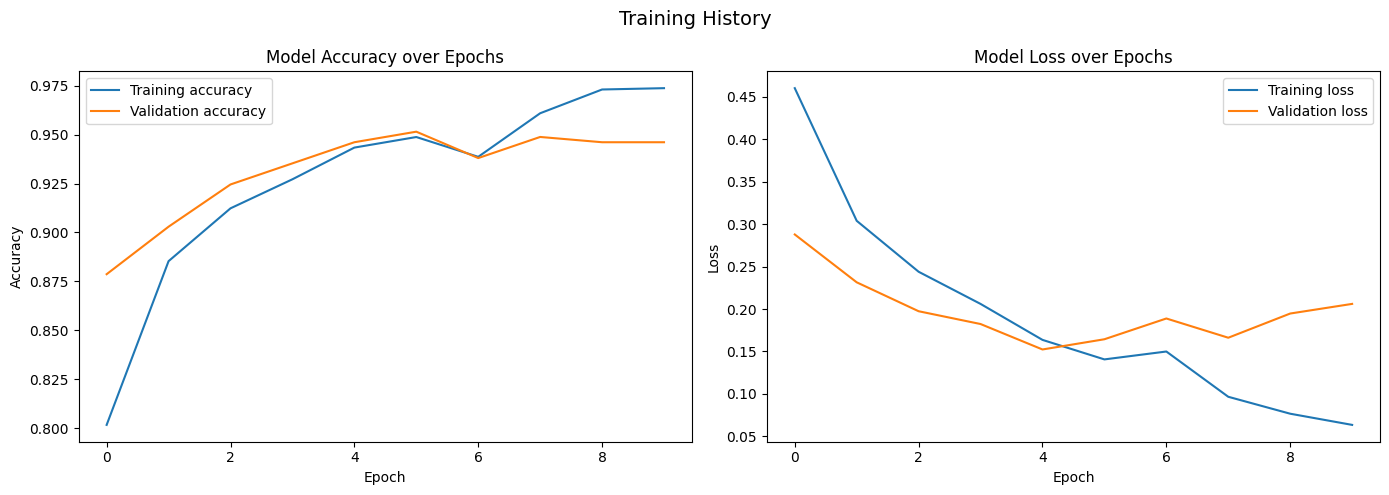

In [11]:
# Plot training history
# history.history is a dictionary containing the metrics recorded each epoch
# keys are 'accuracy', 'val_accuracy', 'loss', 'val_loss'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
# plt.subplots(1, 2) creates 1 row, 2 columns of plots
# (ax1, ax2) unpacks the two axes directly into named variables

# Accuracy plot
ax1.plot(history.history['accuracy'], label='Training accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation accuracy')
ax1.set_title('Model Accuracy over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
# legend() adds the labels we defined with label= to the plot

# Loss plot
ax2.plot(history.history['loss'], label='Training loss')
ax2.plot(history.history['val_loss'], label='Validation loss')
ax2.set_title('Model Loss over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.suptitle('Training History', fontsize=14)
plt.tight_layout()
plt.show()

In [12]:
from google.colab import drive
drive.mount('/content/drive')
# This will ask you to authenticate with your Google account
# Click the link, sign in, copy the code back into Colab

KeyboardInterrupt: 

In [13]:
from google.colab import files

# Save model locally first
model.save('/content/orca_model.keras')

# Download it to your laptop
files.download('/content/orca_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
# cell that loads saved weights instead of rerunning training

# Upload orca_model.keras via the sidebar first, then run this
model.load_weights('/content/orca_model.keras')
print('Weights loaded!')

Weights loaded!


In [10]:
# evaluation:

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
# seaborn is a visualisation library built on top of matplotlib
# it makes certain plots much easier and prettier
# confusion matrices in particular are much cleaner with seaborn

# Get model predictions on the validation set
y_pred_prob = model.predict(X_val)
# model.predict() runs every validation image through the network
# and returns the output probability for each one
# y_pred_prob is an array of numbers between 0 and 1
# e.g. [0.92, 0.03, 0.87, 0.45, ...]

print(f'Prediction shape: {y_pred_prob.shape}')
print(f'First 10 predictions: {y_pred_prob[:10].flatten().round(2)}')
# .flatten() removes the extra dimension so it prints cleanly
# .round(2) rounds to 2 decimal places

12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 255ms/step
Prediction shape: (371, 1)
First 10 predictions: [1.   1.   0.   1.   0.98 1.   1.   1.   1.   0.01]


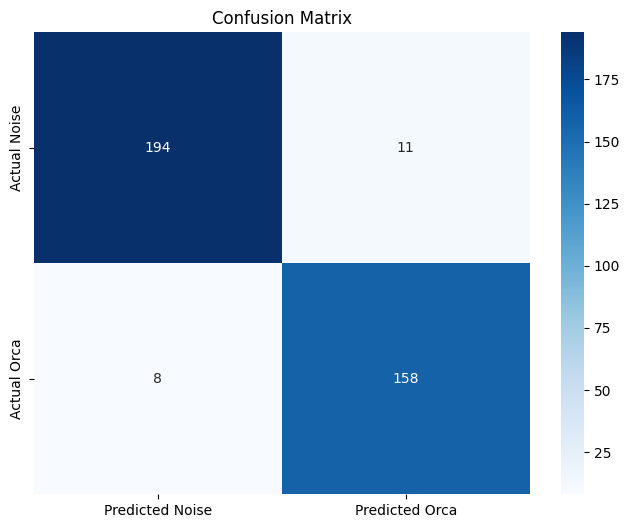

              precision    recall  f1-score   support

       Noise       0.96      0.95      0.95       205
   Orca call       0.93      0.95      0.94       166

    accuracy                           0.95       371
   macro avg       0.95      0.95      0.95       371
weighted avg       0.95      0.95      0.95       371



In [11]:
# Convert probabilities to binary predictions
# anything above 0.5 we call an orca call (1), below 0.5 we call noise (0)
# 0.5 is called the decision threshold - we can adjust this later
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
# > 0.5 creates a boolean array (True/False)
# .astype(int) converts True→1 and False→0
# .flatten() removes the extra dimension

# Build confusion matrix
cm = confusion_matrix(y_val, y_pred)
# confusion_matrix compares actual labels (y_val) vs predicted labels (y_pred)
# and counts how many fall into each category

# Plot it
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Noise', 'Predicted Orca'],
            yticklabels=['Actual Noise', 'Actual Orca'])
# annot=True writes the numbers inside each cell
# fmt='d' means format as integers not scientific notation
# cmap='Blues' makes it a blue colour scale
plt.title('Confusion Matrix')
plt.show()

# Print the full classification report
print(classification_report(y_val, y_pred,
                            target_names=['Noise', 'Orca call']))
# classification_report gives precision, recall and f1 score
# for each class - more informative than accuracy alone

Threshold: 0.4
              precision    recall  f1-score   support

       Noise       0.97      0.93      0.95       205
   Orca call       0.91      0.96      0.94       166

    accuracy                           0.94       371
   macro avg       0.94      0.95      0.94       371
weighted avg       0.94      0.94      0.94       371



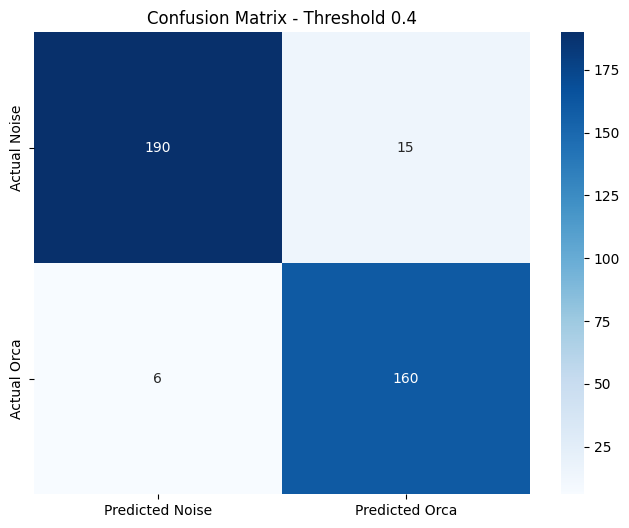

In [12]:
# trying lower decision threshold to get more false positives but less false negatives

# Try a lower decision threshold of 0.4
# Remember y_pred_prob contains our raw probabilities from earlier
y_pred_04 = (y_pred_prob > 0.4).astype(int).flatten()
# Same as before but now anything above 0.4 gets called an orca
# instead of 0.5 - so the model is slightly more trigger happy

# Print the new classification report
print("Threshold: 0.4")
print(classification_report(y_val, y_pred_04,
                            target_names=['Noise', 'Orca call']))

# Plot new confusion matrix
plt.figure(figsize=(8, 6))
cm_04 = confusion_matrix(y_val, y_pred_04)
sns.heatmap(cm_04, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Noise', 'Predicted Orca'],
            yticklabels=['Actual Noise', 'Actual Orca'])
plt.title('Confusion Matrix - Threshold 0.4')
plt.show()

In [13]:
# gonna use a pretrained model from google for better accuracy. Freezing it so I only use a small fraction of it and it doesn't use bare compute
from tensorflow.keras.applications import MobileNetV2
# keras.applications is a library of pretrained models
# MobileNetV2 is one of the most popular lightweight options

# Load MobileNetV2 pretrained on ImageNet
# We exclude the top layers (include_top=False) because those are
# ImageNet-specific classification layers we don't want
# We'll add our own classification layers for orca vs noise
base_model = MobileNetV2(
    input_shape=(128, 128, 3),
    # input_shape must match our image size exactly
    include_top=False,
    # include_top=False means load everything except the final
    # classification layers - we'll add our own
    weights='imagenet'
    # weights='imagenet' loads the pretrained weights
    # this will download them automatically, takes a minute
)

# Freeze the pretrained layers
base_model.trainable = False
# trainable=False means none of these weights will update during training
# we're locking in Google's pretrained knowledge

print(f'Base model layers: {len(base_model.layers)}')
print(f'Base model parameters: {base_model.count_params():,}')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base model layers: 154
Base model parameters: 2,257,984


In [14]:
# this is good now building full model on top of it
from tensorflow.keras import layers, models

# Build the transfer learning model
transfer_model = models.Sequential([
    base_model,
    # the entire pretrained MobileNetV2 as the first layer

    layers.GlobalAveragePooling2D(),
    # GlobalAveragePooling2D is different from the MaxPooling we used before
    # MaxPooling kept the strongest value in each 2x2 block
    # GlobalAveragePooling takes the AVERAGE across the entire feature map
    # and collapses it to a single number per filter
    # so if MobileNetV2 outputs (4, 4, 1280) it becomes just (1280,)
    # this is a smoother, more generalised way to summarise features
    # and is standard practice when using pretrained models

    layers.Dropout(0.3),
    # slightly less aggressive dropout than before (0.3 vs 0.5)
    # because the pretrained features are already robust

    layers.Dense(64, activation='relu'),
    # same as our original model - combine features into a decision

    layers.Dense(1, activation='sigmoid')
    # same binary output - probability of orca call
])

transfer_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,033 (8.93 MB)

 Trainable params: 82,049 (320.50 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [15]:
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    # learning_rate=0.0001 is smaller than the default (0.001)
    # with transfer learning you use a lower learning rate
    # because the pretrained features are already good
    # too large a learning rate risks destabilising them
    # even though they're frozen, the new layers on top
    # can still cause instability if updates are too aggressive
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stopping_transfer = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_transfer = transfer_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping_transfer]
)

print('Training complete!')

Epoch 1/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 39s 662ms/step - accuracy: 0.7485 - loss: 0.5190 - val_accuracy: 0.8976 - val_loss: 0.2999
Epoch 2/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 30s 432ms/step - accuracy: 0.8753 - loss: 0.3268 - val_accuracy: 0.9245 - val_loss: 0.2370
Epoch 3/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 22s 457ms/step - accuracy: 0.8894 - loss: 0.2841 - val_accuracy: 0.9326 - val_loss: 0.1993
Epoch 4/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 22s 467ms/step - accuracy: 0.9016 - loss: 0.2505 - val_accuracy: 0.9434 - val_loss: 0.1798
Epoch 5/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 457ms/step - accuracy: 0.9211 - loss: 0.2170 - val_accuracy: 0.9596 - val_loss: 0.1577
Epoch 6/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 457ms/step - accuracy: 0.9278 - loss: 0.2032 - val_accuracy: 0.9596 - val_loss: 0.1568
Epoch 7/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 42s 468ms/step - accuracy: 0.9272 - loss: 0.2020 - val_accuracy: 0.9515 - val_loss: 0.1597
Epoch 8/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 22s 463ms/step - accuracy: 0.9326 - loss: 0.1874 - val_accu

12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 780ms/step
Transfer Learning Model - Threshold 0.4
              precision    recall  f1-score   support

       Noise       0.94      1.00      0.97       205
   Orca call       0.99      0.93      0.96       166

    accuracy                           0.96       371
   macro avg       0.97      0.96      0.96       371
weighted avg       0.97      0.96      0.96       371



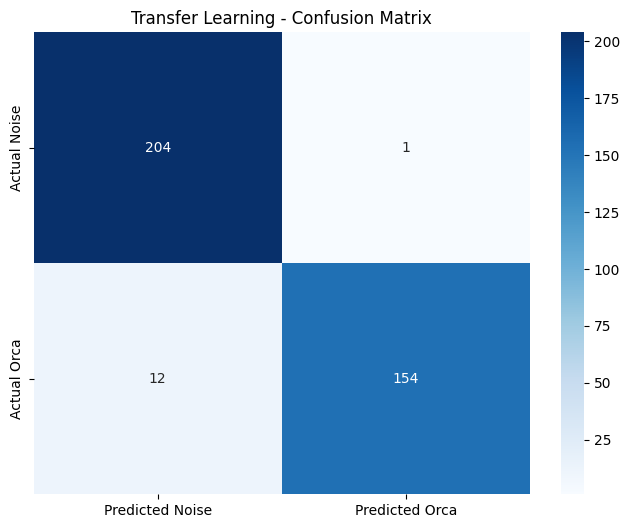

In [16]:
# Get predictions from transfer learning model
y_pred_transfer_prob = transfer_model.predict(X_val)
y_pred_transfer = (y_pred_transfer_prob > 0.4).astype(int).flatten()
# using 0.4 threshold since we decided that was better for recall

print('Transfer Learning Model - Threshold 0.4')
print(classification_report(y_val, y_pred_transfer,
                            target_names=['Noise', 'Orca call']))

# Confusion matrix
plt.figure(figsize=(8, 6))
cm_transfer = confusion_matrix(y_val, y_pred_transfer)
sns.heatmap(cm_transfer, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Noise', 'Predicted Orca'],
            yticklabels=['Actual Noise', 'Actual Orca'])
plt.title('Transfer Learning - Confusion Matrix')
plt.show()

In [17]:
# Try progressively lower thresholds to find the sweet spot
for threshold in [0.4, 0.3, 0.2, 0.1]:
    y_pred_t = (y_pred_transfer_prob > threshold).astype(int).flatten()
    report = classification_report(y_val, y_pred_t,
                                   target_names=['Noise', 'Orca call'],
                                   output_dict=True)
    # output_dict=True returns the report as a dictionary
    # instead of a printed string, so we can extract specific numbers

    orca_recall = report['Orca call']['recall']
    orca_precision = report['Orca call']['precision']
    accuracy = report['accuracy']

    print(f"Threshold {threshold}: orca recall={orca_recall:.3f}, "
          f"orca precision={orca_precision:.3f}, accuracy={accuracy:.3f}")

Threshold 0.4: orca recall=0.928, orca precision=0.994, accuracy=0.965
Threshold 0.3: orca recall=0.934, orca precision=0.987, accuracy=0.965
Threshold 0.2: orca recall=0.946, orca precision=0.924, accuracy=0.941
Threshold 0.1: orca recall=0.964, orca precision=0.894, accuracy=0.933


In [18]:
# fine tuning by unfreezing some more of the data and improving the accuracy. Then will pick a threshold

# Unfreeze the top 30 layers of the base model
# MobileNetV2 has 154 layers total
# Earlier layers detect basic patterns (edges, textures) - keep frozen
# Later layers detect complex patterns - let these adapt to orca data
base_model.trainable = True

# Freeze everything except the last 30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False
# base_model.layers is a list of all layers
# [:-30] means "everything except the last 30"
# setting trainable=False on each one freezes it

# Count how many parameters are now trainable
trainable_count = sum([tf.size(w).numpy()
                       for w in transfer_model.trainable_weights])
print(f'Trainable parameters now: {trainable_count:,}')

Trainable parameters now: 1,608,449


In [19]:
# then recompile
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    # learning_rate=0.00001 - ten times smaller than before
    # this is crucial for fine tuning
    # the unfrozen pretrained weights are already good
    # too large a learning rate would destroy that knowledge
    # we want tiny nudges, not big updates
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stopping_finetune = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Continue training from where we left off
# the model already has good weights, we're just nudging them further
history_finetune = transfer_model.fit(
    X_train, y_train,
    epochs=20,
    # fewer epochs this time - fine tuning converges faster
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping_finetune]
)

print('Fine tuning complete!')

Epoch 1/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 48s 708ms/step - accuracy: 0.6062 - loss: 1.3481 - val_accuracy: 0.9542 - val_loss: 0.1917
Epoch 2/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 29s 622ms/step - accuracy: 0.8409 - loss: 0.4448 - val_accuracy: 0.9542 - val_loss: 0.2109
Epoch 3/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 31s 665ms/step - accuracy: 0.9150 - loss: 0.2412 - val_accuracy: 0.9542 - val_loss: 0.2048
Epoch 4/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 40s 654ms/step - accuracy: 0.9386 - loss: 0.1910 - val_accuracy: 0.9542 - val_loss: 0.2008
Epoch 5/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 29s 619ms/step - accuracy: 0.9481 - loss: 0.1395 - val_accuracy: 0.9569 - val_loss: 0.1837
Epoch 6/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 30s 634ms/step - accuracy: 0.9440 - loss: 0.1539 - val_accuracy: 0.9596 - val_loss: 0.1729
Epoch 7/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 42s 648ms/step - accuracy: 0.9562 - loss: 0.1280 - val_accuracy: 0.9596 - val_loss: 0.1617
Epoch 8/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 30s 631ms/step - accuracy: 0.9602 - loss: 0.1119 - val_accu

In [20]:
# this didn't even make it better!
# have restore_best_weights (or something) =True so should be fine
# gonna save model before moving on
from google.colab import files

# Save the transfer learning model before we lose it
transfer_model.save('/content/transfer_model.keras')
files.download('/content/transfer_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
# then run the threshold sweep on the fine tuned one
y_pred_finetune_prob = transfer_model.predict(X_val)

for threshold in [0.4, 0.3, 0.2, 0.1]:
    y_pred_t = (y_pred_finetune_prob > threshold).astype(int).flatten()
    report = classification_report(y_val, y_pred_t,
                                   target_names=['Noise', 'Orca call'],
                                   output_dict=True)
    orca_recall = report['Orca call']['recall']
    orca_precision = report['Orca call']['precision']
    accuracy = report['accuracy']
    print(f"Threshold {threshold}: orca recall={orca_recall:.3f}, "
          f"orca precision={orca_precision:.3f}, accuracy={accuracy:.3f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 571ms/step
Threshold 0.4: orca recall=0.922, orca precision=0.987, accuracy=0.960
Threshold 0.3: orca recall=0.940, orca precision=0.981, accuracy=0.965
Threshold 0.2: orca recall=0.940, orca precision=0.969, accuracy=0.960
Threshold 0.1: orca recall=0.952, orca precision=0.946, accuracy=0.954


In [ ]:
# actually at 0.1 the fine tuned one does give most balanced results. There's not much in it tho
# gonna leave it for today so make sure saved
from google.colab import files
transfer_model.save('/content/transfer_model.keras')
files.download('/content/transfer_model.keras')
#and save copy to github